In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 결측치 시각화를 위한 라이브러리
import missingno

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

# 다중공선성 확인을 위햔 라이브러리
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [2]:
train_df = pd.read_csv('5_잔액정보_segment_병합.csv')

In [3]:
X = train_df[['잔액_일시불_B0M', '월중평잔_일시불_B0M', '월중평잔_일시불','평잔_일시불_3M','평잔_일시불_6M']]
X = add_constant(X)

In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Data columns (total 6 columns):
 #   Column        Dtype  
---  ------        -----  
 0   const         float64
 1   잔액_일시불_B0M    int64  
 2   월중평잔_일시불_B0M  int64  
 3   월중평잔_일시불      int64  
 4   평잔_일시불_3M     int64  
 5   평잔_일시불_6M     int64  
dtypes: float64(1), int64(5)
memory usage: 109.9 MB


In [5]:
vif = pd.DataFrame()
vif["변수"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

             변수        VIF
0         const   1.331652
1    잔액_일시불_B0M  11.463875
2  월중평잔_일시불_B0M  26.447103
3      월중평잔_일시불  25.394005
4     평잔_일시불_3M  18.616740
5     평잔_일시불_6M  11.052343


- 잔액_일시불_B0M과 월중평잔_일시불, 평잔_일시불_6M을 선택하여 한번 더 다중공선성 확인

In [64]:
X1 = train_df[['잔액_일시불_B0M','월중평잔_일시불','평잔_일시불_6M']]
X1 = add_constant(X1)

In [66]:
vif = pd.DataFrame()
vif["변수"] = X1.columns
vif["VIF"] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]
print(vif)

           변수        VIF
0       const   1.331643
1  잔액_일시불_B0M   6.647221
2    월중평잔_일시불  11.142465
3   평잔_일시불_6M   6.806874


- 3가지 컬럼 확인 결과 잔액_일시불_B0M과 평잔_일시불_6M을 다시 한번 다중 공선성 확인

In [72]:
X2 = train_df[['잔액_일시불_B0M','평잔_일시불_6M']]
X2 = add_constant(X2)

In [74]:
vif = pd.DataFrame()
vif["변수"] = X2.columns
vif["VIF"] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
print(vif)

           변수       VIF
0       const  1.330444
1  잔액_일시불_B0M  4.009327
2   평잔_일시불_6M  4.009327


- 잔액_일시불_B0M, 평잔_일시불_6M끼리의 다중공선성 확인 시 5 미만으로 확인
- 어느정도 다중공선성이 해소 되었다 생각 할 수 있다.

- 잔액_일시불_B0M, 월중평잔_일시불, 평잔_일시불_6M을 EDA

### 잔액_일시불_B0M EDA

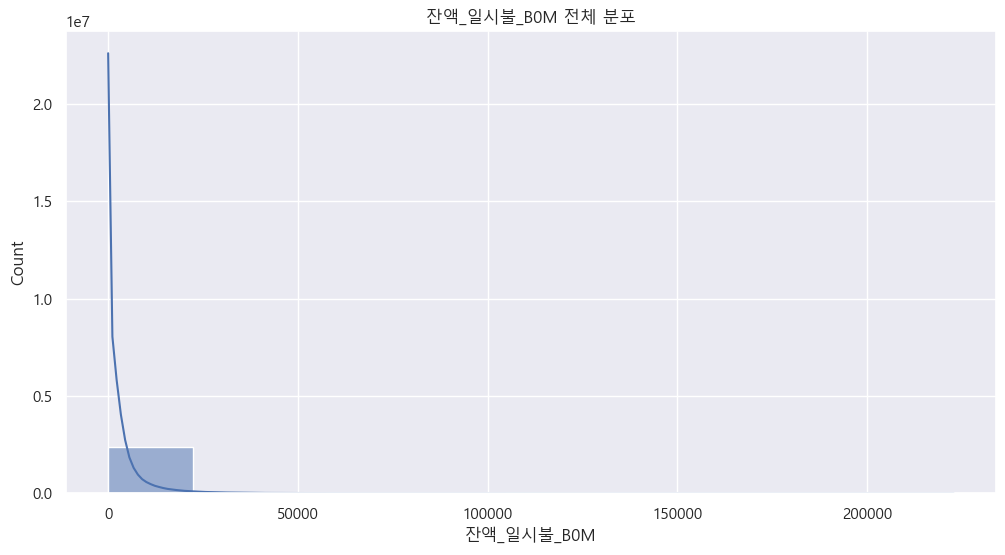

In [8]:
sns.histplot(train_df['잔액_일시불_B0M'], bins=10, kde=True)
plt.title('잔액_일시불_B0M 전체 분포')
plt.show()

In [9]:
Q1 = train_df['잔액_일시불_B0M'].quantile(0.25)
Q3 = train_df['잔액_일시불_B0M'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"IQR 기준 이상치 경계: {lower} ~ {upper}")
print(f"이상치 수: {(train_df['잔액_일시불_B0M'] > upper).sum()}")

IQR 기준 이상치 경계: -5667.0 ~ 9445.0
이상치 수: 200982


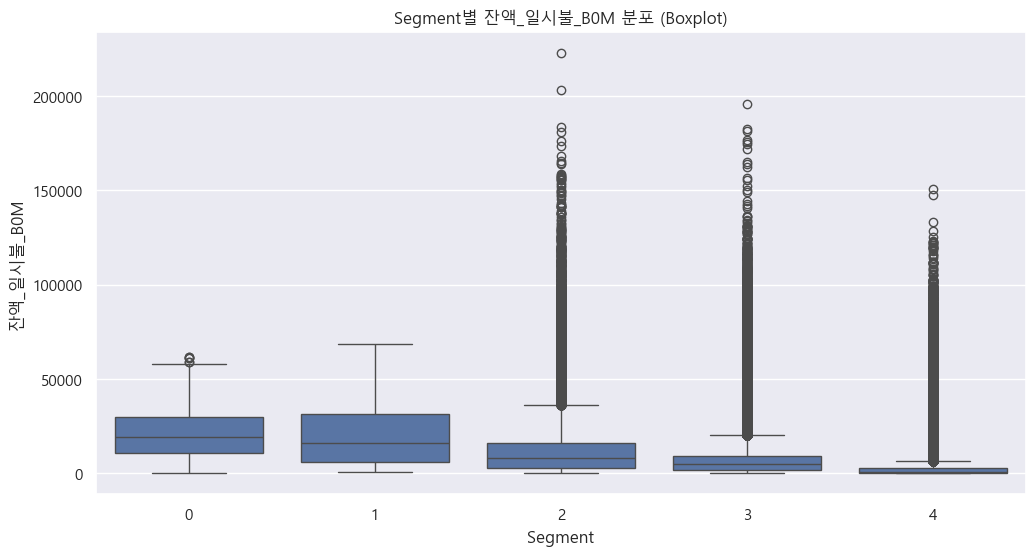

In [10]:
sns.boxplot(data=train_df, x='Segment', y='잔액_일시불_B0M')
plt.title('Segment별 잔액_일시불_B0M 분포 (Boxplot)')
plt.show()

- 2,3,4에 이상치가 많이 분포하며 0은 이상치가 조금 분포하고 있다.

In [12]:
train_df.groupby('Segment')['잔액_일시불_B0M'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()

,Segment,count,mean,median,std,min,max
0,0,972,20699.614198,19025.0,13245.460706,0,61480
1,1,144,19377.381944,15890.5,15524.948205,854,68429
2,2,127590,11505.366870,8019.5,12500.461422,0,222767
3,3,349242,7208.856063,4760.0,9193.192008,0,196046
4,4,1922052,2039.213382,802.0,4092.610674,0,150595


- 0과 1은 수가 적고 4가 가장많다.
- 평균을 보면 0>1>2>3>4 순이다.
- 중앙값 역시 0>1>2>3>4 순이다.

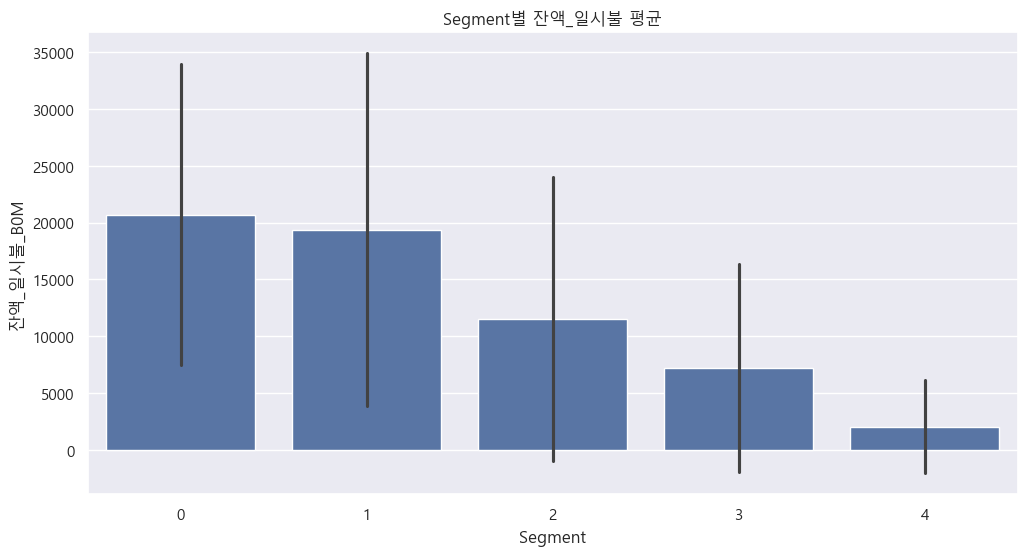

In [14]:
sns.barplot(x='Segment', y='잔액_일시불_B0M', data=train_df, estimator='mean', ci='sd')
plt.title('Segment별 잔액_일시불 평균')
plt.show()

In [62]:
from scipy.stats import f_oneway

groups = [group['잔액_일시불_B0M'].dropna().values for name, group in train_df.groupby('Segment')]
f_stat, p_val = f_oneway(*groups)

print(f"F-통계량: {f_stat:.2f}, p-value: {format(p_val, '.16e')}")

F-통계량: 126911.89, p-value: 0.0000000000000000e+00


### 월중평잔_일시불 EDA

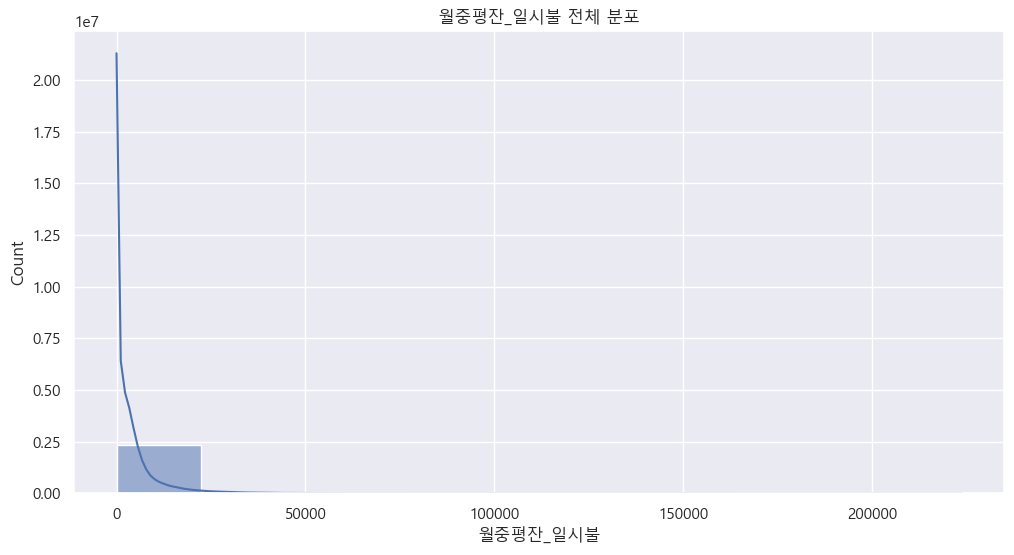

In [17]:
sns.histplot(train_df['월중평잔_일시불'], bins=10, kde=True)
plt.title('월중평잔_일시불 전체 분포')
plt.show()

In [18]:
Q1 = train_df['월중평잔_일시불'].quantile(0.25)
Q3 = train_df['월중평잔_일시불'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"IQR 기준 이상치 경계: {lower} ~ {upper}")
print(f"이상치 수: {(train_df['월중평잔_일시불'] > upper).sum()}")

IQR 기준 이상치 경계: -6918.0 ~ 11530.0
이상치 수: 192092


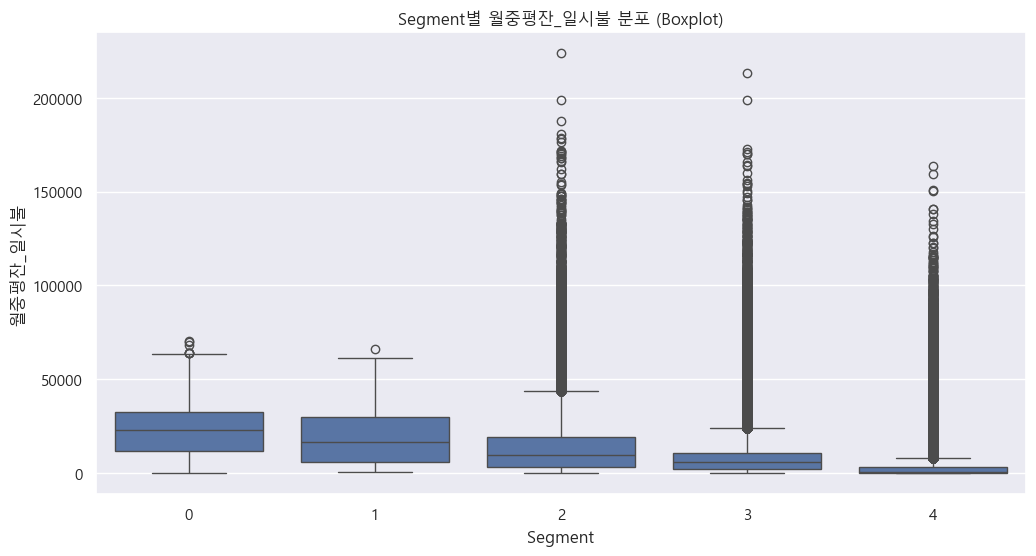

In [19]:
sns.boxplot(data=train_df, x='Segment', y='월중평잔_일시불')
plt.title('Segment별 월중평잔_일시불 분포 (Boxplot)')
plt.show()

- 이상치가 0과 1은 조금만 분포하고 있고 2,3,4는 많이 분포하고있다.

In [21]:
train_df.groupby('Segment')['월중평잔_일시불'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()

,Segment,count,mean,median,std,min,max
0,0,972,23660.139918,23296.5,14498.036972,0,70662
1,1,144,19716.819444,16579.5,15801.003540,672,66325
2,2,127590,13293.476370,9871.5,13427.271179,0,223695
3,3,349242,8239.827326,5817.5,9699.932409,0,213083
4,4,1922052,2371.698193,809.0,4420.557812,0,163820


- 평균을 보면 0>1>2>3>4 순이다.
- 중앙값 역시 0>1>2>3>4 순이다.

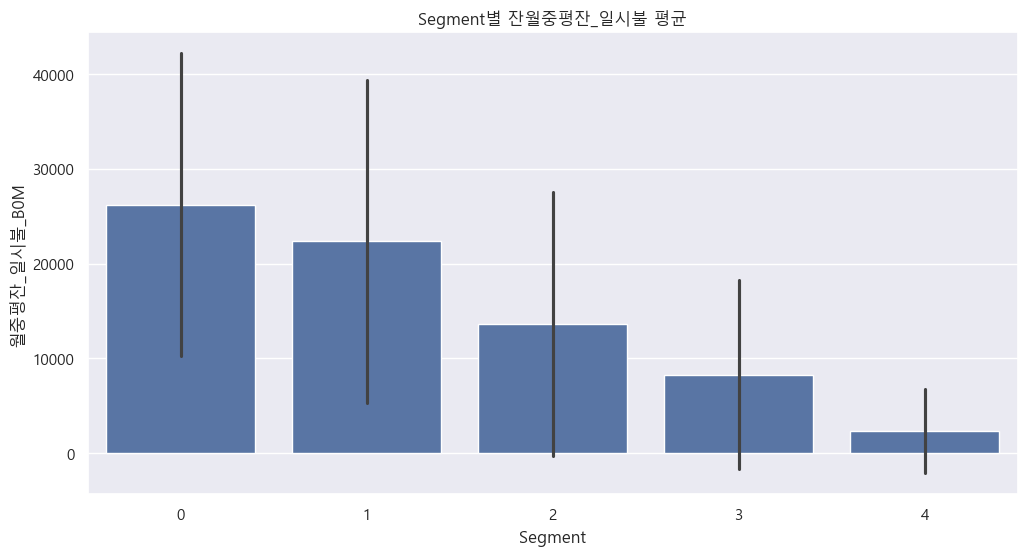

In [23]:
sns.barplot(x='Segment', y='월중평잔_일시불_B0M', data=train_df, estimator='mean', ci='sd')
plt.title('Segment별 잔월중평잔_일시불 평균')
plt.show()

In [45]:
groups = [group['월중평잔_일시불'].dropna().values for name, group in train_df.groupby('Segment')]
f_stat, p_val = f_oneway(*groups)

print(f"F-통계량: {f_stat:.2f}, p-value: {p_val:.4f}")

F-통계량: 145568.52, p-value: 0.0


### 평잔_일시불_6M EDA

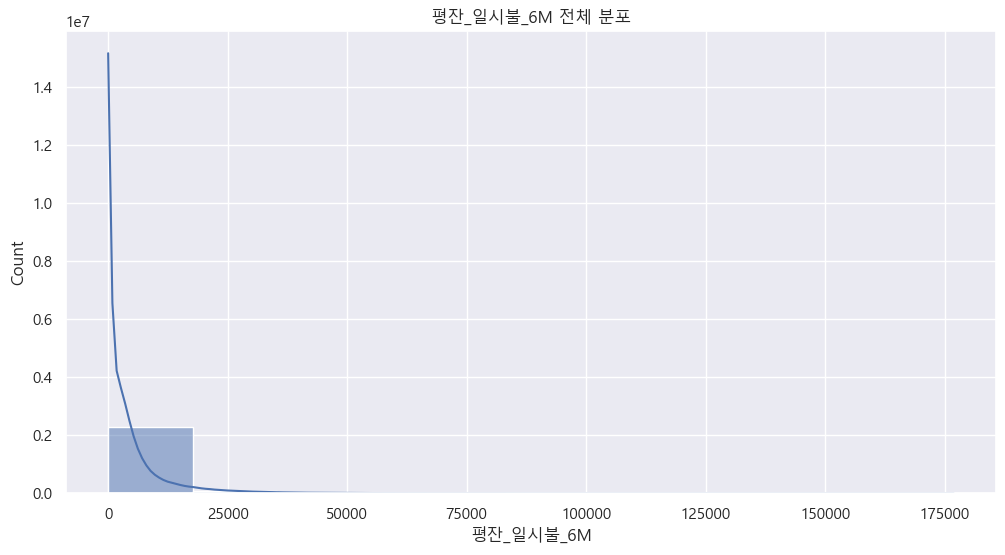

In [26]:
sns.histplot(train_df['평잔_일시불_6M'], bins=10, kde=True)
plt.title('평잔_일시불_6M 전체 분포')
plt.show()

In [27]:
Q1 = train_df['평잔_일시불_6M'].quantile(0.25)
Q3 = train_df['평잔_일시불_6M'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"IQR 기준 이상치 경계: {lower} ~ {upper}")
print(f"이상치 수: {(train_df['잔액_일시불_B0M'] > upper).sum()}")

IQR 기준 이상치 경계: -7281.5 ~ 12418.5
이상치 수: 134766


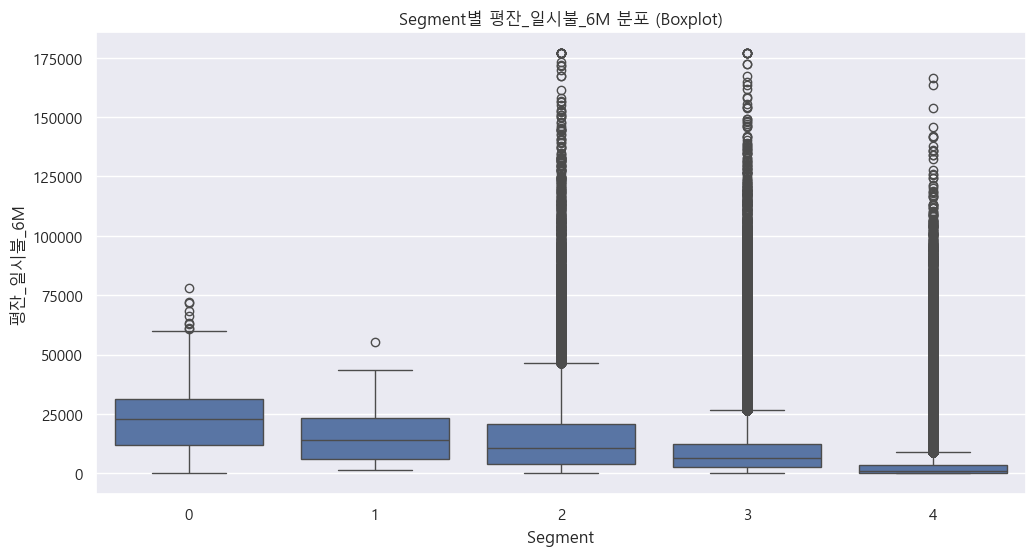

In [28]:
sns.boxplot(data=train_df, x='Segment', y='평잔_일시불_6M')
plt.title('Segment별 평잔_일시불_6M 분포 (Boxplot)')
plt.show()

- 이상치가 0과 1은 조금만 분포하고 있고 2,3,4는 많이 분포하고있다.

In [30]:
train_df.groupby('Segment')['평잔_일시불_6M'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()

,Segment,count,mean,median,std,min,max
0,0,972,23138.444444,22736.0,14039.852518,29,77858
1,1,144,16162.847222,13796.0,11732.966144,1293,55337
2,2,127590,14118.216788,10689.0,13557.286300,0,176861
3,3,349242,9045.806925,6376.0,9996.733316,0,176861
4,4,1922052,2640.088545,985.0,4766.977045,0,166448


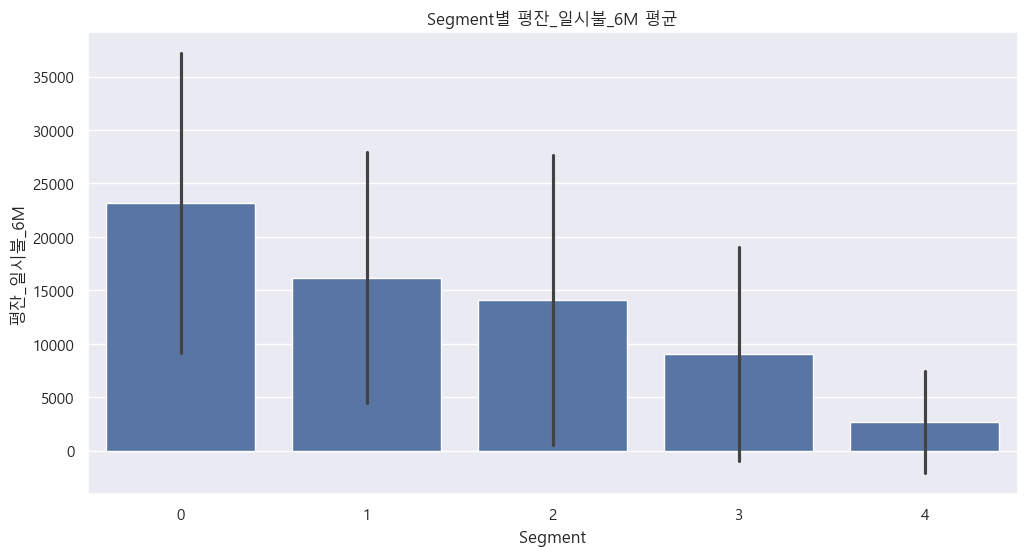

In [31]:
sns.barplot(x='Segment', y='평잔_일시불_6M', data=train_df, estimator='mean', ci='sd')
plt.title('Segment별 평잔_일시불_6M 평균')
plt.show()

- 평균을 보면 0>1>2>3>4 순이다.
- 중앙값 역시 0>1>2>3>4 순이다.

In [33]:
groups = [group['평잔_일시불_6M'].dropna().values for name, group in train_df.groupby('Segment')]
f_stat, p_val = f_oneway(*groups)

print(f"F-통계량: {f_stat:.2f}, p-value: {p_val:.4f}")

F-통계량: 151396.54, p-value: 0.0
